# Load data

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum as spark_sum
from pyspark.sql.functions import weekofyear, dayofweek, month, hour, floor, col
from pyspark.sql.functions import mean
from pyspark.sql.functions import *
import networkx as nx

In [2]:
spark = SparkSession.builder.appName("FlightProject").getOrCreate()
raw_path = "/Users/huynhphuongchi/Downloads/flights_sample_2m.csv"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/16 06:15:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/16 06:15:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/16 06:15:31 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/16 06:15:31 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/16 06:15:31 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/03/16 06:15:31 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/03/16 06:15:31 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.


In [3]:
df = spark.read.option("header",True).option("inferSchema",True).csv(raw_path).repartition(32)

df.createOrReplaceTempView("flight_data_2019_2023")

26/03/16 06:15:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [4]:
df_cleaned = df.select('*')

# General information

In [5]:
df.printSchema()
df.show(truncate=False)

root
 |-- FL_DATE: date (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- AIRLINE_DOT: string (nullable = true)
 |-- AIRLINE_CODE: string (nullable = true)
 |-- DOT_CODE: integer (nullable = true)
 |-- FL_NUMBER: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- ORIGIN_CITY: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- DEST_CITY: string (nullable = true)
 |-- CRS_DEP_TIME: integer (nullable = true)
 |-- DEP_TIME: double (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: double (nullable = true)
 |-- WHEELS_ON: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: integer (nullable = true)
 |-- ARR_TIME: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CANCELLED: double (nullable = true)
 |-- CANCELLATION_CODE: string (nullable = true)
 |-- DIVERTED: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)

+----------+----------------------------------+--------------------------------------+------------+--------+---------+------+-------------------+----+---------------------+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|FL_DATE   |AIRLINE                           |AIRLINE_DOT                           |AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|ORIGIN_CITY        |DEST|DEST_CITY            |CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+----------+----------------------------------+--------------------------------------+--------

In [6]:
num_cores = spark.sparkContext.defaultParallelism
print(f"Spark is using {num_cores} cores.")

Spark is using 10 cores.


In [7]:
df.rdd.getNumPartitions()

32

In [8]:
df.explain(True)

== Parsed Logical Plan ==
Repartition 32, true
+- Relation [FL_DATE#17,AIRLINE#18,AIRLINE_DOT#19,AIRLINE_CODE#20,DOT_CODE#21,FL_NUMBER#22,ORIGIN#23,ORIGIN_CITY#24,DEST#25,DEST_CITY#26,CRS_DEP_TIME#27,DEP_TIME#28,DEP_DELAY#29,TAXI_OUT#30,WHEELS_OFF#31,WHEELS_ON#32,TAXI_IN#33,CRS_ARR_TIME#34,ARR_TIME#35,ARR_DELAY#36,CANCELLED#37,CANCELLATION_CODE#38,DIVERTED#39,CRS_ELAPSED_TIME#40,ELAPSED_TIME#41,... 7 more fields] csv

== Analyzed Logical Plan ==
FL_DATE: date, AIRLINE: string, AIRLINE_DOT: string, AIRLINE_CODE: string, DOT_CODE: int, FL_NUMBER: int, ORIGIN: string, ORIGIN_CITY: string, DEST: string, DEST_CITY: string, CRS_DEP_TIME: int, DEP_TIME: double, DEP_DELAY: double, TAXI_OUT: double, WHEELS_OFF: double, WHEELS_ON: double, TAXI_IN: double, CRS_ARR_TIME: int, ARR_TIME: double, ARR_DELAY: double, CANCELLED: double, CANCELLATION_CODE: string, DIVERTED: double, CRS_ELAPSED_TIME: double, ELAPSED_TIME: double, ... 7 more fields
Repartition 32, true
+- Relation [FL_DATE#17,AIRLINE#18,AI

## Semantics of Flight Data Columns
- **FL_DATE** – The date of the flight
- **AIRLINE** – The airline name
- **AIRLINE_DOT** – The official DOT (Department of Transportation) code assigned to the airline
- **AIRLINE_CODE** – Airline **short** code
- **DOT_CODE** – DOT code of airline
- **FL_NUMBER** – The flight number assigned by the airline for this route.  
- **ORIGIN** – The airport code where the flight departed.  
- **ORIGIN_CITY** – The city of the origin airport.  
- **DEST** – The airport code where the flight arrived.  
- **DEST_CITY** – The city of the destination airport.  
- **CRS_DEP_TIME** – The scheduled departure time according to the flight plan.  
- **DEP_TIME** – The actual time when the flight took off.  
- **DEP_DELAY** – The delay in departure, difference between scheduled and actual departure time (minutes)
- **TAXI_OUT** – Time taken to taxi from the gate to the runway before takeoff (minutes)
- **WHEELS_OFF** – The exact time when the aircraft’s wheels leave the runway
- **WHEELS_ON** – The exact time when the aircraft’s wheels touch down on the runway
- **TAXI_IN** – Time taken to taxi from the runway to the arrival gate (minutes)
- **CRS_ARR_TIME** – The scheduled arrival time according to the flight plan.  
- **ARR_TIME** – The actual arrival time of the flight.  
- **ARR_DELAY** – The delay in arrival in minutes; difference between scheduled and actual arrival time (minutes)  
- **CANCELLED** –  Flight cancelled (0 = no, 1 = yes)
- **CANCELLATION_CODE** –  Reason for cancellation  
- **DIVERTED** – Flight diverted (0 = no, 1 = yes)
- **CRS_ELAPSED_TIME** –  Scheduled flight duration (minutes)
- **ELAPSED_TIME** – Actual duration of the flight (minutes)
- **AIR_TIME** – The time the plane spent in the air between takeoff and landing (minutes)
- **DISTANCE** – Distance between airports (miles)
- **DELAY_DUE_CARRIER** – Delay caused by airline (minutes)
- **DELAY_DUE_WEATHER** – Delay caused by weather (minutes)
- **DELAY_DUE_NAS** – Delay caused by National Airspace System (NAS) issues like traffic or congestion (minutes)
- **DELAY_DUE_SECURITY** – Delay due to security procedures or checks (minutes)
- **DELAY_DUE_LATE_AIRCRAFT** – Delay caused by the aircraft arriving late from a previous flight (minutes)

> AIRLINE, AIRLINE_CODE,AIRLINE_DOT, DOT_CODE: Norminal variable with the same object for each value
> -  Drop AIRLINE, AIRLINE_DOT
> -  Keep AIRLINE_CODE, DOT_CODE to analyse easier

DEP_TIME -> TAXI_OUT (min)-> WHEELS_OFF-> AIR_TIME (min)-> WHEELS_ON-> TAXI_IN(min)-> ARR_TIME

> (!) no need to check: *ARR_TIME > DEP_TIME*
and *WHEELS_ON > WHEELS_OFF* because of: overnight flights, time zone differences

In [9]:
#Drop columns
df_cleaned = df_cleaned.drop("AIRLINE", "AIRLINE_DOT","ORIGIN_CITY","DEST_CITY")

In [10]:
def hhmm_to_minutes(col):
    return (F.floor(col/100) * 60 + (col % 100))

## Statistic

In [11]:
# count number of rows and columns
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 2000000
Columns: 32


In [12]:
df.describe().show()

+-------+--------------------+--------------------+------------+------------------+------------------+-------+------------+-------+------------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-----------------+-------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+-------------------+-----------------------+
|summary|             AIRLINE|         AIRLINE_DOT|AIRLINE_CODE|          DOT_CODE|         FL_NUMBER| ORIGIN| ORIGIN_CITY|   DEST|   DEST_CITY|     CRS_DEP_TIME|          DEP_TIME|         DEP_DELAY|          TAXI_OUT|        WHEELS_OFF|         WHEELS_ON|          TAXI_IN|     CRS_ARR_TIME|          ARR_TIME|         ARR_DELAY|         CANCELLED|CANCELLATION_CODE|           DIVERTED|  CRS_ELAPSED_TIME|      ELAPSED_TIME|          

> - DISTANCE: no negative, no == 0.
> - DEP_DELAY, ARR_DELAY: negative value means early/no delay.

> Need to check:
> - Time variables (CRS_DEP_TIME,DEP_TIME, WHEELS_OFF, WHEELS_ON,CRS_ARR_TIME, ARR_TIME):  min == 00:00, max == 23:59, minute shoulb be < 60
> - Duration variables (CRS_ELAPSED_TIME, ELAPSED_TIME, AIR_TIME, TAXI_OUT, TAXI_IN): cannot be negative.

In [ ]:
#Check for invalid minute values
time_columns = [
    "CRS_DEP_TIME",
    "DEP_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "CRS_ARR_TIME",
    "ARR_TIME"
]

print("Checking for invalid minute values (>=60) in time columns:")
for column_name in time_columns:
    # filter for rows where the minute part is 60 or greater
    invalid_count = df.filter((col(column_name) % 100) >= 60).count()
    print(f"Column '{column_name}': {invalid_count} rows have minute values >= 60.")


Checking for invalid minute values (>=60) in time columns:


Column 'CRS_DEP_TIME': 0 rows have minute values >= 60.
Column 'DEP_TIME': 0 rows have minute values >= 60.
Column 'WHEELS_OFF': 0 rows have minute values >= 60.
Column 'WHEELS_ON': 0 rows have minute values >= 60.
Column 'CRS_ARR_TIME': 0 rows have minute values >= 60.
Column 'ARR_TIME': 0 rows have minute values >= 60.


In [14]:
df.count()

2000000

In [ ]:
#Convert 24:00 into 00:00
time_columns_to_convert = [
    "DEP_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "CRS_ARR_TIME",
    "ARR_TIME"]

# loop through each time column and replace 2400 with 0
for column_name in time_columns_to_convert:
    df_cleaned = df_cleaned.withColumn(
        column_name,
        F.when(F.col(column_name) == 2400, 0).otherwise(F.col(column_name)))

print("Time values '2400' have been converted to '0000' (numeric 0) in the specified columns.")

Time values '2400' have been converted to '0000' (numeric 0) in the specified columns.


In [16]:
df_cleaned.describe().show()

+-------+------------+-----------------+------------------+-------+-------+-----------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+------------------+-----------------+-------------------+-----------------+-------------------+------------------+------------------+------------------+----------------+-----------------+-----------------+------------------+-------------------+-----------------------+
|summary|AIRLINE_CODE|         DOT_CODE|         FL_NUMBER| ORIGIN|   DEST|     CRS_DEP_TIME|          DEP_TIME|         DEP_DELAY|          TAXI_OUT|        WHEELS_OFF|         WHEELS_ON|          TAXI_IN|      CRS_ARR_TIME|          ARR_TIME|        ARR_DELAY|          CANCELLED|CANCELLATION_CODE|           DIVERTED|  CRS_ELAPSED_TIME|      ELAPSED_TIME|          AIR_TIME|        DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|     DELAY_DUE_NAS| DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+-------+---

In [17]:
df_cleaned.filter(col("CRS_ELAPSED_TIME") < 0).count()

1

In [18]:
df_cleaned.filter(col("CRS_ELAPSED_TIME") < 0).show(truncate=False)

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|FL_DATE   |AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+--------------

In [ ]:
#drop rows with negative value in col CRS_ELAPSED_TIME
df_cleaned = df_cleaned.filter(
    (F.col("CRS_ELAPSED_TIME").isNull()) | (F.col("CRS_ELAPSED_TIME") >= 0))

print("Number of rows now:", df_cleaned.count())

Number of rows now: 1999999


# Data quality

## Check duplicate values

In [20]:
df_cleaned.count() - df_cleaned.dropDuplicates().count()

0

## Check unique values

In [21]:
for col_name in df_cleaned.columns:
    print(f"The column '{col_name}' has {df_cleaned.select(col_name).distinct().count()} unique values.")

The column 'FL_DATE' has 1704 unique values.
The column 'AIRLINE_CODE' has 18 unique values.
The column 'DOT_CODE' has 18 unique values.
The column 'FL_NUMBER' has 7087 unique values.
The column 'ORIGIN' has 380 unique values.
The column 'DEST' has 380 unique values.


The column 'CRS_DEP_TIME' has 1387 unique values.


The column 'DEP_TIME' has 1441 unique values.


The column 'DEP_DELAY' has 1408 unique values.
The column 'TAXI_OUT' has 177 unique values.


The column 'WHEELS_OFF' has 1441 unique values.


...

The column 'ELAPSED_TIME' has 694 unique values.
The column 'AIR_TIME' has 663 unique values.


The column 'DISTANCE' has 1720 unique values.


The column 'DELAY_DUE_CARRIER' has 1208 unique values.


The column 'DELAY_DUE_WEATHER' has 697 unique values.
The column 'DELAY_DUE_NAS' has 564 unique values.
The column 'DELAY_DUE_SECURITY' has 142 unique values.


The column 'DELAY_DUE_LATE_AIRCRAFT' has 867 unique values.


> DEP_TIME,ARR_TIME, WHEELS_OFF, WHEELS_ON: 1441 > 1440 (total minutes of a day), may have NULL

In [22]:
df_cleaned.select("DEP_TIME").distinct().orderBy("DEP_TIME").show(5)

+--------+
|DEP_TIME|
+--------+
|    NULL|
|     0.0|
|     1.0|
|     2.0|
|     3.0|
+--------+
only showing top 5 rows


## Data error

In [ ]:
#DELAY_CAUSES < ARR_DELAP
df_check_error = df.withColumn(
    "TOTAL_CAUSE_DELAY",
    F.col("DELAY_DUE_CARRIER") +
    F.col("DELAY_DUE_WEATHER") +
    F.col("DELAY_DUE_NAS") +
    F.col("DELAY_DUE_SECURITY") +
    F.col("DELAY_DUE_LATE_AIRCRAFT"))

In [ ]:
delay_error = df_check_error.filter(
    F.col("TOTAL_CAUSE_DELAY") > F.col("ARR_DELAY"))

delay_error.count()

0

# Missing value

In [25]:
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, NumericType)]
exclude = ["FL_NUMBER","DOT_CODE", "CANCELLED","DIVERTED"]

numeric_cols = [c for c in numeric_cols if c not in exclude]
print(numeric_cols)

['CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']


In [ ]:
missing_df = df_cleaned.select([
    spark_sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_cleaned.columns])
# change to pandas to show all
missing_pd = missing_df.toPandas().T
missing_pd.columns = ["missing_count"]
missing_pd["missing_percent"] = (missing_pd["missing_count"] / df_cleaned.count()) * 100
missing_pd.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
CANCELLATION_CODE,1947477,97.373899
DELAY_DUE_LATE_AIRCRAFT,1643780,82.189041
DELAY_DUE_SECURITY,1643780,82.189041
DELAY_DUE_NAS,1643780,82.189041
DELAY_DUE_WEATHER,1643780,82.189041
DELAY_DUE_CARRIER,1643780,82.189041
AIR_TIME,57231,2.861551
ELAPSED_TIME,57231,2.861551
ARR_DELAY,57231,2.861551
WHEELS_ON,53091,2.654551


In [27]:
df_cleaned.filter(F.col("CRS_ELAPSED_TIME").isNull()).show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+--------------

In [28]:
df_cleaned.filter(F.col("CANCELLED") == 1).count()

52522

In [29]:
#drop rows with missing in CRE_ELAPSED_TIME (17 rows)
df_cleaned = df_cleaned.filter(F.col("CRS_ELAPSED_TIME").isNotNull())

In [30]:
df_cleaned.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_cleaned.columns]).show()

+-------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+-------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------

- ARR_DELAY = ELAPSED_TIME = AIR_TIME = 57214
- WHEELS_ON = TAXI_IN = ARR_TIME = 53074
- WHEELS_OFF = TAXI_OUT = 52264
- DELAY_DUE_CARRIER = DELAY_DUE_WEATHER = DELAY_DUE_NAS = DELAY_DUE_SECURITY = DELAY_DUE_LATE_AIRCRAFT = 1643763


In [31]:
df_cleaned.filter((F.col("DEP_TIME").isNull()) & (F.col("DEP_DELAY").isNull())).count()

51414

In [ ]:
df_cleaned.groupBy(
    F.col("DEP_TIME").isNull().alias("DEP_TIME_NULL"),
    F.col("DEP_DELAY").isNull().alias("DEP_DELAY_NULL"),
    "CANCELLED",
    "DIVERTED").count().orderBy("DEP_TIME_NULL","DEP_DELAY_NULL","CANCELLED","DIVERTED").show()

+-------------+--------------+---------+--------+-------+
|DEP_TIME_NULL|DEP_DELAY_NULL|CANCELLED|DIVERTED|  count|
+-------------+--------------+---------+--------+-------+
|        false|         false|      0.0|     0.0|1942768|
|        false|         false|      0.0|     1.0|   4709|
|        false|         false|      1.0|     0.0|   1072|
|        false|          true|      1.0|     0.0|     19|
|         true|          true|      1.0|     0.0|  51414|
+-------------+--------------+---------+--------+-------+



DEP_TIME + DEP_DELAY null 100% because of CANCELLED

In [33]:
df_check = df_cleaned.filter(F.col("DEP_TIME").isNotNull() & F.col("DEP_DELAY").isNotNull() & (F.col("CANCELLED") == 1))
df_check.count()

1072

In [34]:
df_check.show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+--------------

In [35]:
df_cleaned.filter((F.col("CANCELLED") == 1) & F.col("ARR_TIME").isNotNull()).count()

0

In [36]:
df_cleaned.filter(F.col("CANCELLED") == 0).count()

1947477

In [37]:
df_cleaned.filter(F.col("DIVERTED") == 1).count()

4709

- CANCELLATION_CODE is not null, it's not cancelled

In [38]:
df_cleaned.filter((F.col("CANCELLED") == 1) & (F.col("DIVERTED") == 1)).count()

0

In [ ]:
summary = df_cleaned.groupBy(
    F.col("DEP_DELAY").isNull().alias("DEP_NULL"),
    F.col("ARR_DELAY").isNull().alias("ARR_NULL"),
    "CANCELLED",
    "DIVERTED").count()

summary.orderBy("DEP_NULL","ARR_NULL","CANCELLED","DIVERTED").show()

+--------+--------+---------+--------+-------+
|DEP_NULL|ARR_NULL|CANCELLED|DIVERTED|  count|
+--------+--------+---------+--------+-------+
|   false|   false|      0.0|     0.0|1942768|
|   false|    true|      0.0|     1.0|   4709|
|   false|    true|      1.0|     0.0|   1072|
|    true|    true|      1.0|     0.0|  51433|
+--------+--------+---------+--------+-------+



In [40]:
df_cleaned.filter((F.col("DEP_DELAY").isNull()) & (F.col("ARR_DELAY").isNotNull())).count()

0

- DEP_DELAY == NULL => 100% ARR_DELAY == NULL
- ARR_DELAY == NULL => CANCELLED or DIVERTED (100%)

In [41]:
df_cleaned.filter((F.col("DEP_DELAY").isNotNull()) & (F.col("ARR_DELAY").isNull())).show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CANCELLED|CANCELLATION_CODE|DIVERTED|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+--------------

In [ ]:
# check missing value by CANCELLED and DIVERTED
cols_to_check = ["ARR_DELAY", "ELAPSED_TIME", "AIR_TIME","DEP_TIME", "DEP_DELAY", "TAXI_OUT", "WHEELS_OFF",
    "ARR_TIME", "TAXI_IN", "WHEELS_ON"]

for col in cols_to_check:
    print(f"\nChecking missing in {col} by CANCELLED and DIVERTED")

    df_cleaned.select("CANCELLED", "DIVERTED", col) \
      .withColumn("is_missing", F.col(col).isNull().cast("integer")) \
      .groupBy("CANCELLED", "DIVERTED") \
      .agg(F.sum("is_missing").alias("missing_count"),F.count("*").alias("total_count")) \
      .withColumn("missing_percent", F.col("missing_count") / F.col("total_count") * 100) \
      .orderBy("CANCELLED", "DIVERTED") \
      .show()


Checking missing in ARR_DELAY by CANCELLED and DIVERTED


+---------+--------+-------------+-----------+---------------+
|CANCELLED|DIVERTED|missing_count|total_count|missing_percent|
+---------+--------+-------------+-----------+---------------+
|      0.0|     0.0|            0|    1942768|            0.0|
|      0.0|     1.0|         4709|       4709|          100.0|
|      1.0|     0.0|        52505|      52505|          100.0|
+---------+--------+-------------+-----------+---------------+


Checking missing in ELAPSED_TIME by CANCELLED and DIVERTED


+---------+--------+-------------+-----------+---------------+
|CANCELLED|DIVERTED|missing_count|total_count|missing_percent|
+---------+--------+-------------+-----------+---------------+
|      0.0|     0.0|            0|    1942768|            0.0|
|      0.0|     1.0|         4709|       4709|          100.0|
|      1.0|     0.0|        52505|      52505|          100.0|
+---------+--------+-------------+-----------+---------------+


Checking missing in AIR_TIME by CANCELLED and DIVERTED
+---------+--------+-------------+-----------+---------------+
|CANCELLED|DIVERTED|missing_count|total_count|missing_percent|
+---------+--------+-------------+-----------+---------------+
|      0.0|     0.0|            0|    1942768|            0.0|
|      0.0|     1.0|         4709|       4709|          100.0|
|      1.0|     0.0|        52505|      52505|          100.0|
+---------+--------+-------------+-----------+---------------+


Checking missing in DEP_TIME by CANCELLED and DIVERTED
+---

- All null of "ARR_DELAY", "ELAPSED_TIME", "AIR_TIME" because of CANCELLED or DIVERTED
- All null of "ARR_TIME", "TAXI_IN", and "WHEELS_ON" because of CANCELLED or DIVERTED

=> 100% CANCELLED == 1 => "ARR_DELAY", "ELAPSED_TIME", "AIR_TIME", "ARR_TIME", "TAXI_IN", "WHEELS_ON", "TAXI_OUT", "WHEELS_OFF" null

=> 100% DIVERTED == 1 => "ARR_DELAY", "ELAPSED_TIME", "AIR_TIME" null

DIVERTED == 1 =>  12% "ARR_TIME", "TAXI_IN", "WHEELS_ON" null


In [43]:
# drop rows which flights are CANCELLED
df_cleaned = df_cleaned.filter(F.col("CANCELLED") == 0)

# drop column CANCELLED and CANCELLATION_CODE
df_cleaned = df_cleaned.drop("CANCELLED", "CANCELLATION_CODE")

In [ ]:
# check if DIVERTED is delay or not
df_cleaned.filter(F.col("DIVERTED") == 1).groupBy(
    F.when(F.col("DEP_DELAY").isNull(), "NULL")
     .when(F.col("DEP_DELAY") == 0, "On time")
     .when(F.col("DEP_DELAY") > 0, "Delayed")
     .otherwise("Early")
     .alias("DEP_STATUS")).count().show()

+----------+-----+
|DEP_STATUS|count|
+----------+-----+
|   On time|  215|
|     Early| 2116|
|   Delayed| 2378|
+----------+-----+



In [ ]:
delay_cols = ["DELAY_DUE_CARRIER", "DELAY_DUE_LATE_AIRCRAFT", "DELAY_DUE_SECURITY", "DELAY_DUE_NAS", "DELAY_DUE_WEATHER"]

# create a list of aggregation expressions to count non-nulls for each column
non_null_counts = [F.count(F.col(c)).alias(f"Non_Null_{c}") for c in delay_cols]

# apply the aggregations to the DataFrame and show the results
df_cleaned.agg(*non_null_counts).show()

+--------------------------+--------------------------------+---------------------------+----------------------+--------------------------+
|Non_Null_DELAY_DUE_CARRIER|Non_Null_DELAY_DUE_LATE_AIRCRAFT|Non_Null_DELAY_DUE_SECURITY|Non_Null_DELAY_DUE_NAS|Non_Null_DELAY_DUE_WEATHER|
+--------------------------+--------------------------------+---------------------------+----------------------+--------------------------+
|                    356219|                          356219|                     356219|                356219|                    356219|
+--------------------------+--------------------------------+---------------------------+----------------------+--------------------------+



In [ ]:
# check if ARR_STATUS == early/ontime, delay_columns is non null (count)
condition = None
for c in delay_cols:
    cond = F.col(c).isNotNull()
    condition = cond if condition is None else (condition | cond)

df_cleaned.filter((F.col("ARR_DELAY") <= 0) & condition).count()

0

In [ ]:
df_check = df_cleaned.withColumn(
    "null_count",
    __builtins__.sum(F.col(c).isNull().cast("int") for c in delay_cols) # explicitly use Python's built-in sum for row-wise addition
)
df_check = df_check.withColumn(
    "delay_null_pattern",
    F.when(F.col("null_count") == len(delay_cols), "ALL_NULL")
     .when(F.col("null_count") == 0, "ALL_NOT_NULL")
     .otherwise("MIXED"))
df_check.groupBy("delay_null_pattern").count().show()

+------------------+-------+
|delay_null_pattern|  count|
+------------------+-------+
|          ALL_NULL|1591258|
|      ALL_NOT_NULL| 356219|
+------------------+-------+



In [48]:
df_check.filter(F.col("delay_null_pattern") == "ALL_NOT_NULL").select("ARR_DELAY").describe().show()

+-------+-----------------+
|summary|        ARR_DELAY|
+-------+-----------------+
|  count|           356219|
|   mean|67.72818406654334|
| stddev|94.90357059309424|
|    min|             15.0|
|    max|           3237.0|
+-------+-----------------+



In [49]:
df_check.filter(F.col("delay_null_pattern") == "ALL_NULL").select("ARR_DELAY").describe().show()

+-------+------------------+
|summary|         ARR_DELAY|
+-------+------------------+
|  count|           1586549|
|   mean|-9.939690485449866|
| stddev|11.349848383265194|
|    min|            -119.0|
|    max|              14.0|
+-------+------------------+



All flights with ARR_DELAY <= 15mins => Delay_columns (DELAY_DUE_XXX) NULL

In [50]:
df_cleaned.filter((F.col("ARR_DELAY") > 14) & (F.col("DIVERTED") == 1)).count()

0

100% DIVERTED don't have any record reason for delayed or diverted

In [ ]:
# drop all rows with diverted
df_cleaned = df_cleaned.filter(F.col("DIVERTED") == 0)
# drop columns DIVERTED
df_cleaned = df_cleaned.drop("DIVERTED")

In [ ]:
# replace NULL in delay_cols by 0
for c in delay_cols:
    df_cleaned = df_cleaned.withColumn(c, F.when(F.col(c).isNull(), 0).otherwise(F.col(c)))
    df_cleaned = df_cleaned.withColumn(c, F.col(c).cast("int"))

In [ ]:
#re-check missing values
df_cleaned.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_cleaned.columns]).show()

+-------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|
+-------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+
|      0|           0|       0|        0|     0|   0|           0|       0|        0|       0|         0|    

# Distribution

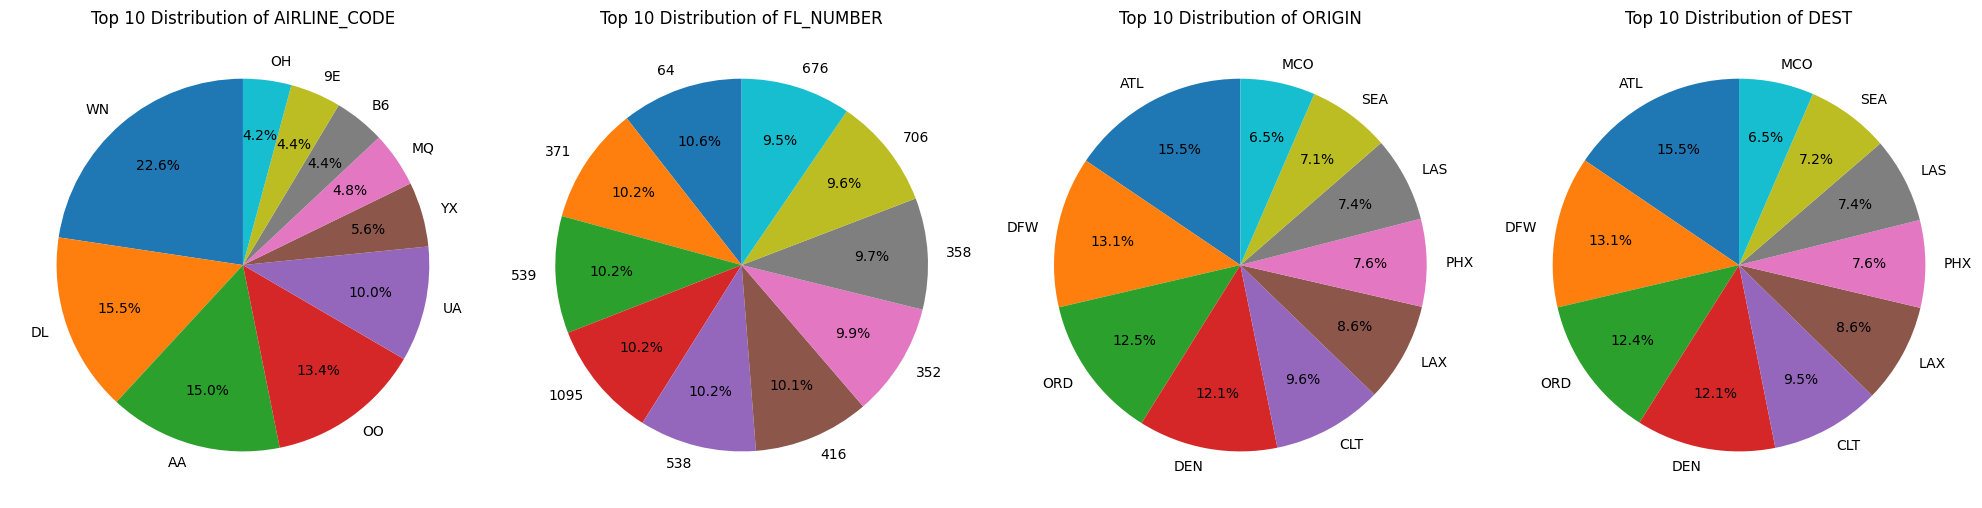

In [ ]:
variables = ["AIRLINE_CODE", "FL_NUMBER", "ORIGIN", "DEST"]

pdf = df.select(variables).toPandas()

fig, axes = plt.subplots(1, len(variables), figsize=(20, 6))

for i, var in enumerate(variables):

    counts = pdf[var].value_counts().head(10)

    counts.plot.pie(
        ax=axes[i],
        autopct="%.1f%%",
        pctdistance=0.7,
        startangle=90)

    axes[i].set_title(f"Top 10 Distribution of {var}")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

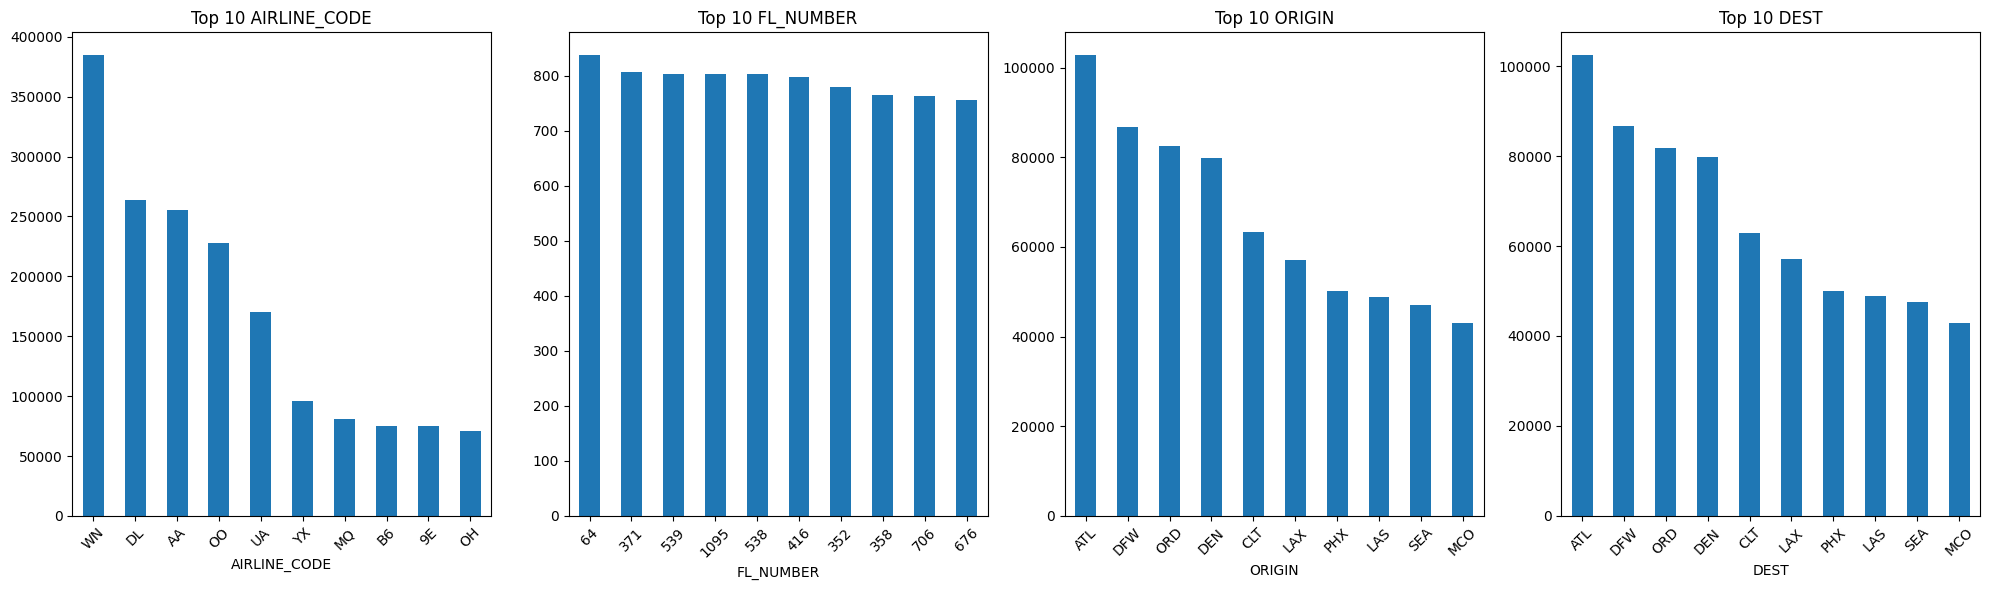

In [55]:
fig, axes = plt.subplots(1, len(variables), figsize=(20,6))

for i, var in enumerate(variables):

    pdf[var].value_counts().head(10).plot.bar(ax=axes[i])

    axes[i].set_title(f"Top 10 {var}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## DEP_DELAY

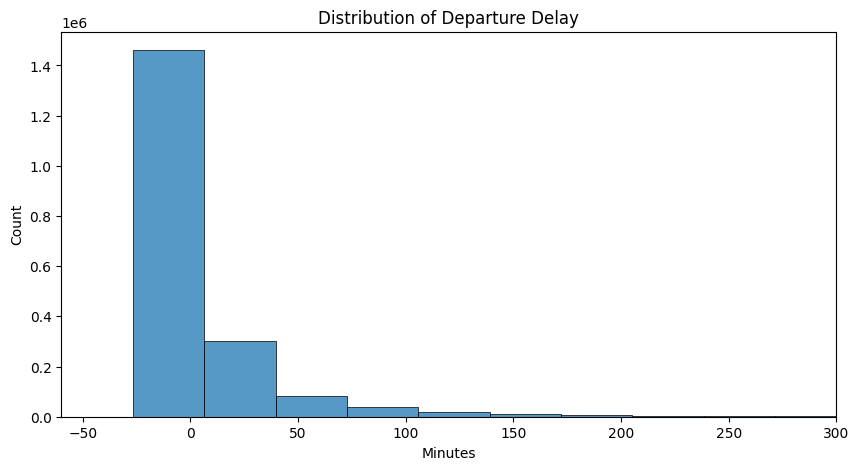

In [ ]:
pdf = df_cleaned.select("DEP_DELAY","ARR_DELAY").toPandas()

plt.figure(figsize=(10,5))
sns.histplot(pdf["DEP_DELAY"], bins=100)

plt.xlim(-60,300)   # avoid outlier 3000+
plt.title("Distribution of Departure Delay")
plt.xlabel("Minutes")
plt.show()

In [ ]:
dep_status = df_cleaned.groupBy(
    F.when(F.col("DEP_DELAY").isNull(), "NULL")
     .when(F.col("DEP_DELAY") == 0, "On time")
     .when(F.col("DEP_DELAY") > 0, "Delayed")
     .otherwise("Early")
     .alias("DEP_STATUS")).count()
dep_status.show()

+----------+-------+
|DEP_STATUS|  count|
+----------+-------+
|   On time|  94676|
|     Early|1187745|
|   Delayed| 660347|
+----------+-------+



In [58]:
df_cleaned.approxQuantile("DEP_DELAY",[0.01,0.05,0.5,0.95,0.99],0)

[-14.0, -10.0, -2.0, 72.0, 191.0]

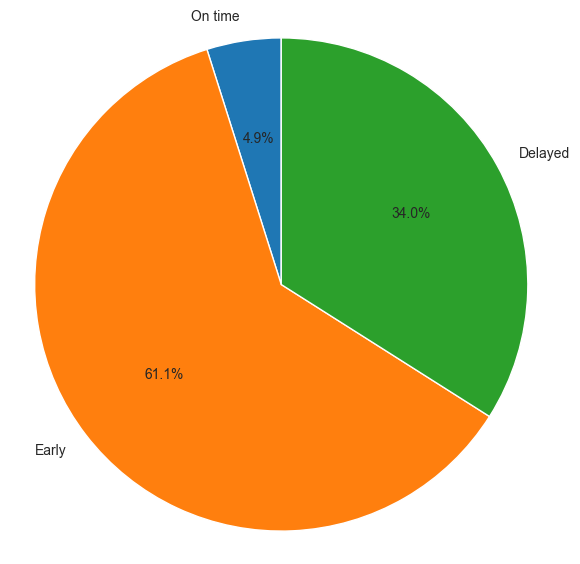

In [ ]:
#distribution of Departure Status
dep_status_pd = dep_status.toPandas()
labels = dep_status_pd["DEP_STATUS"]
values = dep_status_pd["count"]

sns.set_style("white")

plt.figure(figsize=(7,7))

plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)

plt.axis('equal')
plt.show()

## ARR_DELAY

+----------+-------+
|ARR_STATUS|  count|
+----------+-------+
|   On time|  35805|
|     Early|1254992|
|   Delayed| 651971|
+----------+-------+



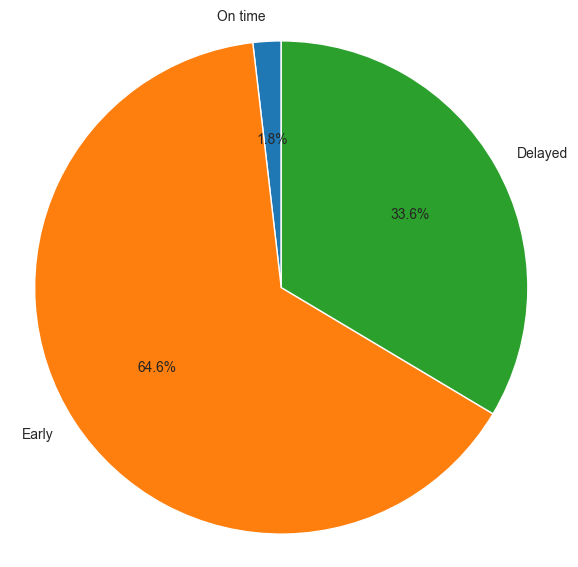

In [ ]:
#distribution of Arrival Status
arr_status = df_cleaned.groupBy(
    F.when(F.col("ARR_DELAY").isNull(), "NULL")
     .when(F.col("ARR_DELAY") == 0, "On time")
     .when(F.col("ARR_DELAY") > 0, "Delayed")
     .otherwise("Early")
     .alias("ARR_STATUS")).count()

arr_status.show()

# Pie chart for ARR_STATUS
arr_status_pd = arr_status.toPandas()

labels = arr_status_pd["ARR_STATUS"]
values = arr_status_pd["count"]

sns.set_style("white")

plt.figure(figsize=(7,7))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90)

plt.axis('equal')
plt.show()

## DEP_DELAY and ARR_DELAY

In [ ]:
df_cleaned.filter(
    (F.col("DEP_DELAY") > 0) &
    (F.col("ARR_DELAY") < 0)).count()

172973

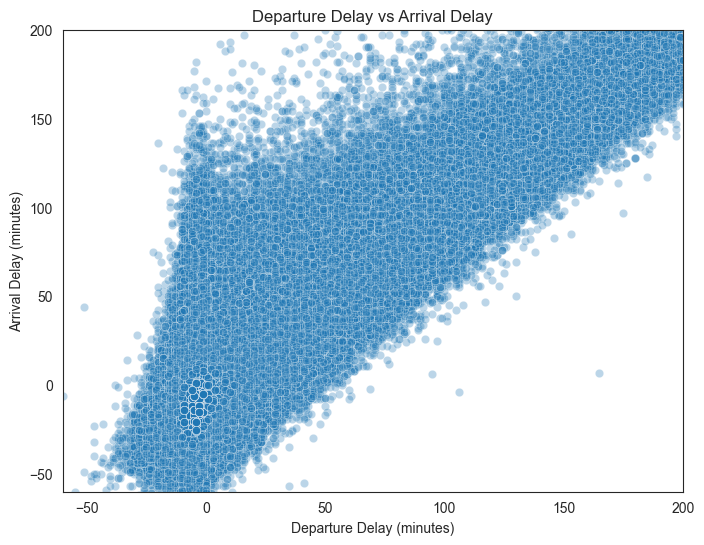

In [ ]:
pdf = df_cleaned.select(
    "DEP_DELAY",
    "ARR_DELAY").toPandas()

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="DEP_DELAY",
    y="ARR_DELAY",
    data=pdf,
    alpha=0.3,)

plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Arrival Delay (minutes)")

plt.xlim(-60,200)
plt.ylim(-60,200)

plt.show()

In [ ]:
df_cleaned.filter((F.col("DEP_DELAY") < -40) & (F.col("ARR_DELAY") > 150)).count()

0

In [ ]:
df_cleaned.filter((F.col("DEP_DELAY") > 100) & (F.col("ARR_DELAY") < -20)).count()

0

## Delays by Hour

In [65]:
# create "DAY_OF_WEEK", "MONTH", "HOUR" feature to analyze
df_cleaned = df_cleaned.withColumn("Hour", F.floor(F.col("CRS_DEP_TIME") / 100)) \
       .withColumn("DayOfWeek", F.dayofweek(F.col("FL_DATE"))) \
       .withColumn("Month", F.month(F.col("FL_DATE")))

In [ ]:
delays_by_hour = df_cleaned.groupBy("Hour").agg(
    F.count("*").alias("total_flights"),
    spark_sum(F.when(F.col("DEP_DELAY") > 0, 1).otherwise(0)).alias("delayed_flights"),
    spark_sum(F.when(F.col("DELAY_DUE_CARRIER") > 0,1).otherwise(0)).alias("carrier_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_WEATHER") > 0,1).otherwise(0)).alias("weather_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_NAS") > 0,1).otherwise(0)).alias("nas_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_SECURITY") > 0,1).otherwise(0)).alias("security_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_LATE_AIRCRAFT") > 0,1).otherwise(0)).alias("late_aircraft_delay"))

delays_by_hour = delays_by_hour.withColumn("delay_rate", F.col("delayed_flights") / F.col("total_flights"))

In [67]:
delays_by_hour_pd = delays_by_hour.orderBy("Hour").toPandas()

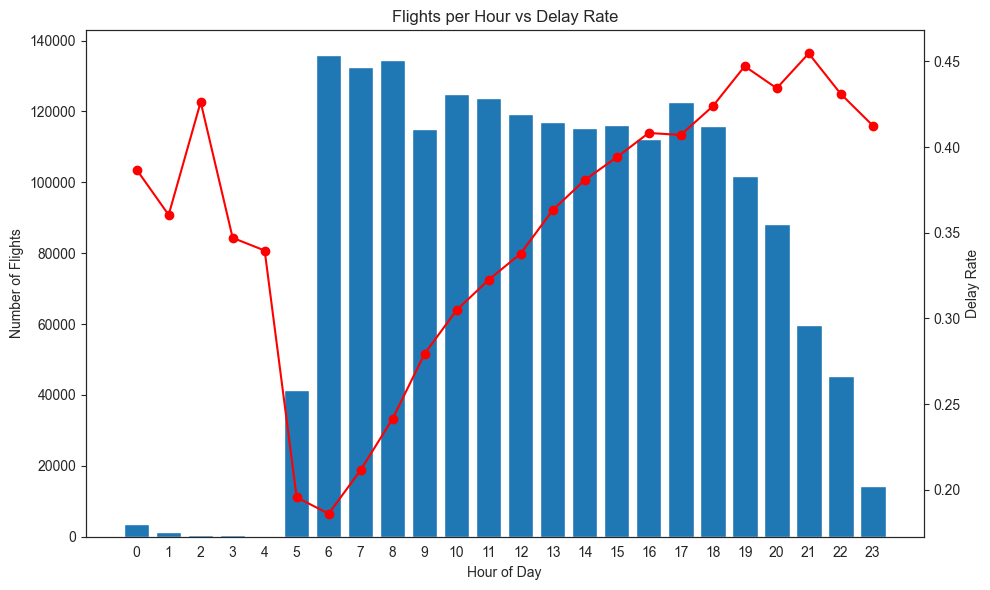

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart: flights per hour
ax1.bar(
    delays_by_hour_pd["Hour"],
    delays_by_hour_pd["total_flights"],
    label="Flights")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of Flights")

ax1.set_xticks(range(24))

# Line chart: delay rate
ax2 = ax1.twinx()

ax2.plot(
    delays_by_hour_pd["Hour"],
    delays_by_hour_pd["delay_rate"],
    color="red",
    marker="o",
    label="Delay Rate")

ax2.set_ylabel("Delay Rate")
plt.title("Flights per Hour vs Delay Rate")
fig.tight_layout()
plt.show()

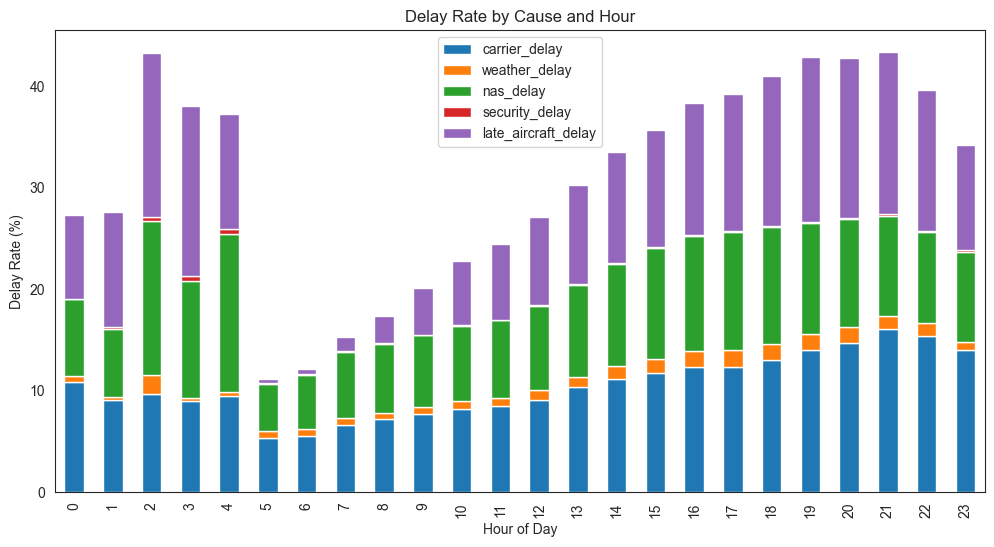

In [ ]:
cause_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"]

for col in cause_cols:
    delays_by_hour_pd[col] = delays_by_hour_pd[col] / delays_by_hour_pd["total_flights"]*100

delays_by_hour_pd.set_index("Hour")[cause_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6))

plt.title("Delay Rate by Cause and Hour")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Hour of Day")

plt.show()

## Delay by Weekday

In [ ]:
delays_by_day = df_cleaned.groupBy("DayOfWeek").agg(
    F.count("*").alias("total_flights"),
    spark_sum(F.when(F.col("DEP_DELAY") > 0, 1).otherwise(0)).alias("delayed_flights"),
    spark_sum(F.when(F.col("DELAY_DUE_CARRIER") > 0,1).otherwise(0)).alias("carrier_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_WEATHER") > 0,1).otherwise(0)).alias("weather_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_NAS") > 0,1).otherwise(0)).alias("nas_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_SECURITY") > 0,1).otherwise(0)).alias("security_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_LATE_AIRCRAFT") > 0,1).otherwise(0)).alias("late_aircraft_delay"))

In [ ]:
delays_by_day = delays_by_day.withColumn("delay_rate", F.col("delayed_flights") / F.col("total_flights"))

In [72]:
delays_by_day_pd = delays_by_day.orderBy("DayOfWeek").toPandas()

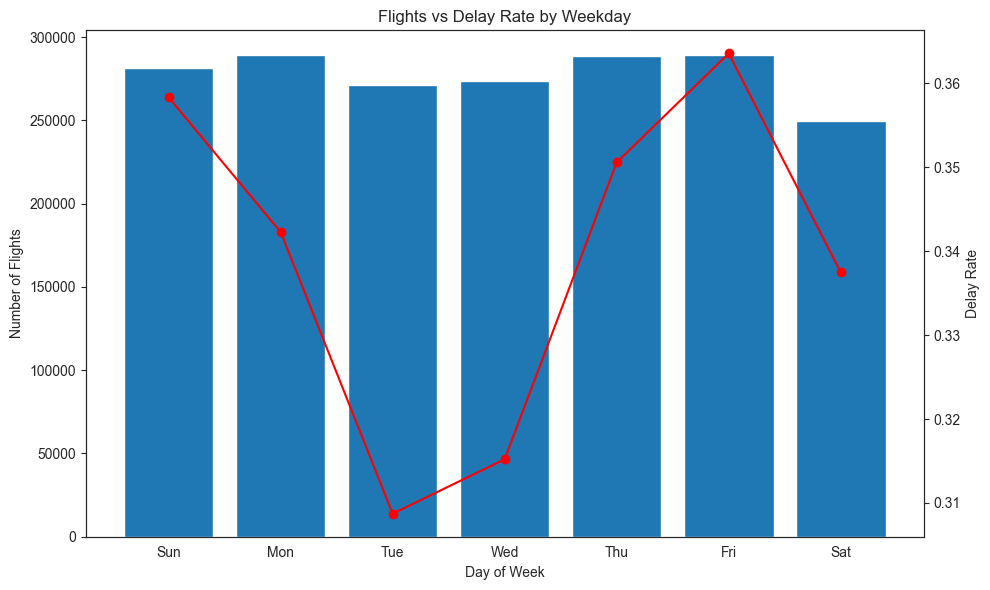

In [ ]:
weekday_map = {
1:"Sun",2:"Mon",3:"Tue",4:"Wed",5:"Thu",6:"Fri",7:"Sat"}

delays_by_day_pd["Weekday"] = delays_by_day_pd["DayOfWeek"].map(weekday_map)
fig, ax1 = plt.subplots(figsize=(10,6))

# Flights
ax1.bar(delays_by_day_pd["Weekday"], delays_by_day_pd["total_flights"], label="Flights")

ax1.set_ylabel("Number of Flights")
ax1.set_xlabel("Day of Week")

# Delay rate
ax2 = ax1.twinx()

ax2.plot(
    delays_by_day_pd["Weekday"],
    delays_by_day_pd["delay_rate"],
    color="red",
    marker="o",
    label="Delay Rate"
)

ax2.set_ylabel("Delay Rate")

plt.title("Flights vs Delay Rate by Weekday")

plt.tight_layout()
plt.show()

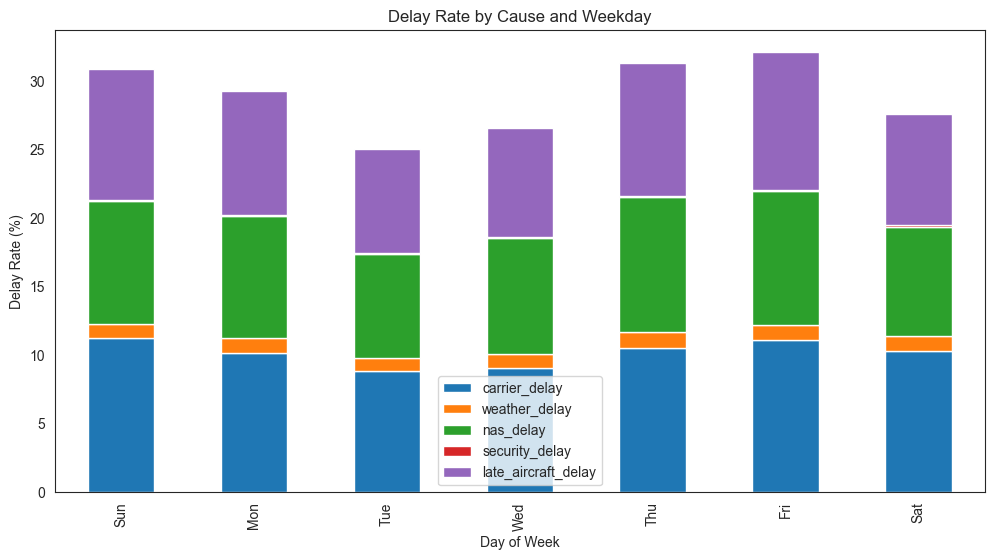

In [74]:
for col in cause_cols:
    delays_by_day_pd[col] = delays_by_day_pd[col] / delays_by_day_pd["total_flights"] * 100

delays_by_day_pd.set_index("Weekday")[cause_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Delay Rate by Cause and Weekday")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Day of Week")

plt.show()

## Delay by Month

In [75]:
delays_by_month = df_cleaned.groupBy("Month").agg(
    F.count("*").alias("total_flights"),
    spark_sum(
        F.when(F.col("DEP_DELAY") > 0, 1).otherwise(0)
    ).alias("delayed_flights"),
    spark_sum(F.when(F.col("DELAY_DUE_CARRIER") > 0,1).otherwise(0)).alias("carrier_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_WEATHER") > 0,1).otherwise(0)).alias("weather_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_NAS") > 0,1).otherwise(0)).alias("nas_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_SECURITY") > 0,1).otherwise(0)).alias("security_delay"),
    spark_sum(F.when(F.col("DELAY_DUE_LATE_AIRCRAFT") > 0,1).otherwise(0)).alias("late_aircraft_delay")
)

In [76]:
delays_by_month = delays_by_month.withColumn(
    "delay_rate",
    F.col("delayed_flights") / F.col("total_flights")
)
delays_by_month_pd = delays_by_month.orderBy("Month").toPandas()

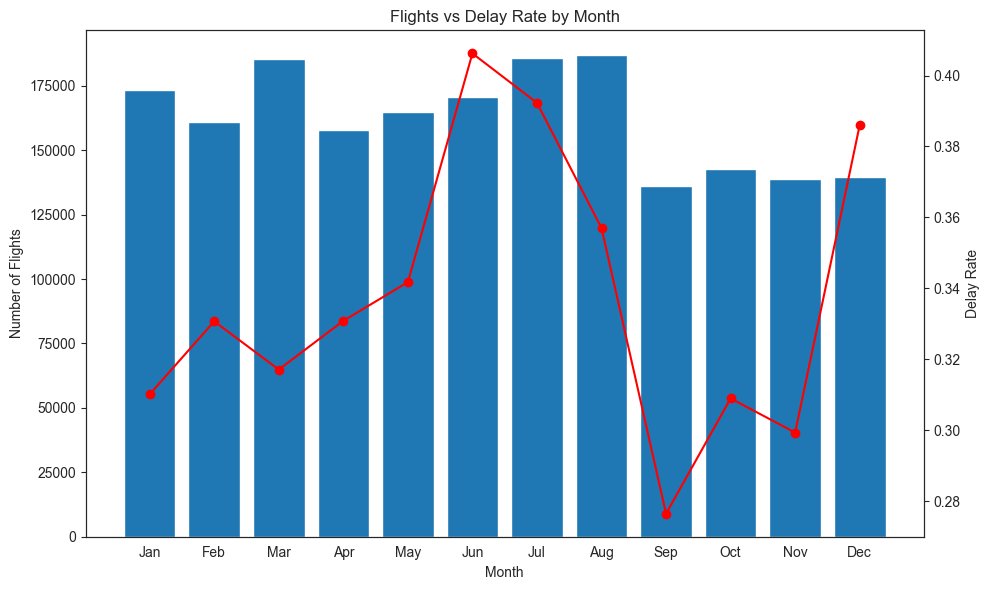

In [77]:
month_map = {
1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

delays_by_month_pd["MonthName"] = delays_by_month_pd["Month"].map(month_map)
fig, ax1 = plt.subplots(figsize=(10,6))

# Flights
ax1.bar(
    delays_by_month_pd["MonthName"],
    delays_by_month_pd["total_flights"],
    label="Flights"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Flights")

# Delay rate
ax2 = ax1.twinx()

ax2.plot(
    delays_by_month_pd["MonthName"],
    delays_by_month_pd["delay_rate"],
    color="red",
    marker="o",
    label="Delay Rate"
)

ax2.set_ylabel("Delay Rate")

plt.title("Flights vs Delay Rate by Month")

plt.tight_layout()
plt.show()

In [ ]:
cause_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay"]

for col in cause_cols:
    delays_by_month_pd[col] = delays_by_month_pd[col] / delays_by_month_pd["total_flights"] * 100

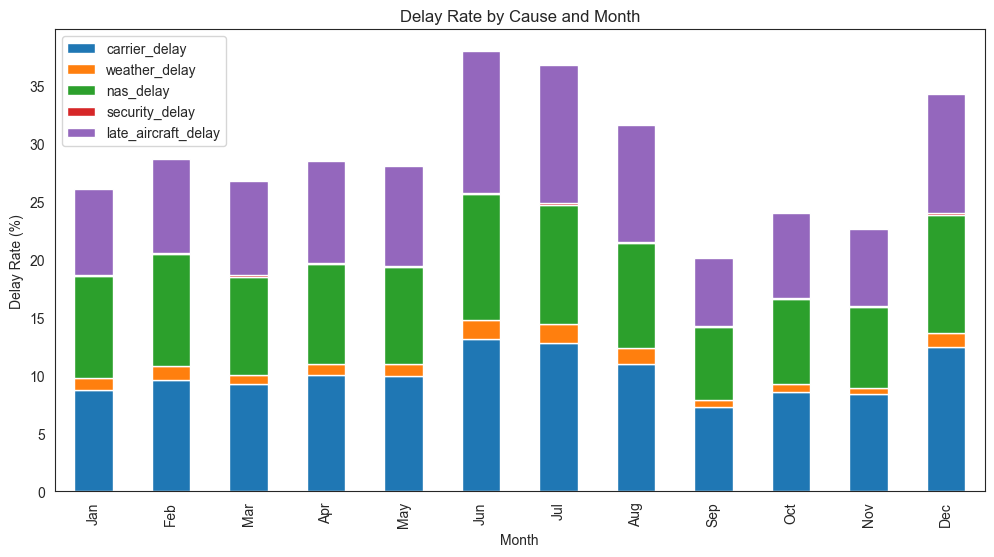

In [ ]:
delays_by_month_pd.set_index("MonthName")[cause_cols].plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Delay Rate by Cause and Month")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Month")
plt.show()

## Delays by Causes

In [ ]:
delay_totals = df_cleaned.select([
    spark_sum(F.when(F.col(c) > 0, 1).otherwise(0)).alias(c)
    for c in delay_cols])
delay_totals.show()
delay_totals_pd = delay_totals.toPandas()

+-----------------+-----------------------+------------------+-------------+-----------------+
|DELAY_DUE_CARRIER|DELAY_DUE_LATE_AIRCRAFT|DELAY_DUE_SECURITY|DELAY_DUE_NAS|DELAY_DUE_WEATHER|
+-----------------+-----------------------+------------------+-------------+-----------------+
|           197980|                 172701|              1872|       171290|            21006|
+-----------------+-----------------------+------------------+-------------+-----------------+



In [ ]:
delay_counts = df_cleaned.select([
    spark_sum(F.when(F.col(c) > 0, 1).otherwise(0)).alias(c)
    for c in delay_cols])
delay_counts.show()

+-----------------+-----------------------+------------------+-------------+-----------------+
|DELAY_DUE_CARRIER|DELAY_DUE_LATE_AIRCRAFT|DELAY_DUE_SECURITY|DELAY_DUE_NAS|DELAY_DUE_WEATHER|
+-----------------+-----------------------+------------------+-------------+-----------------+
|           197980|                 172701|              1872|       171290|            21006|
+-----------------+-----------------------+------------------+-------------+-----------------+



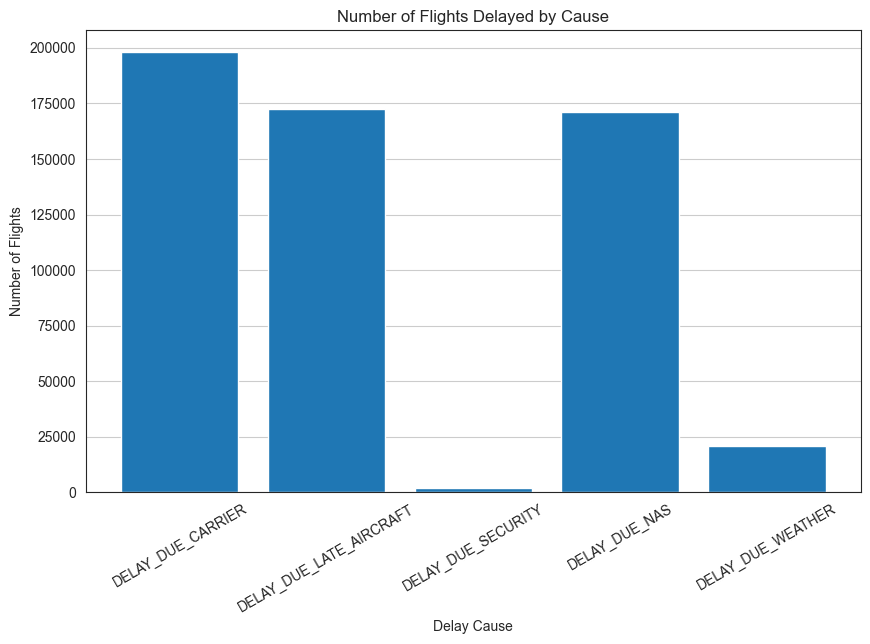

In [ ]:
delay_counts_pd = delay_counts.toPandas()

labels = delay_counts_pd.columns
values = delay_counts_pd.iloc[0].values
sns.set_style("white")
plt.figure(figsize=(10,6))
plt.bar(labels, values)
plt.title("Number of Flights Delayed by Cause")
plt.xlabel("Delay Cause")
plt.ylabel("Number of Flights")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

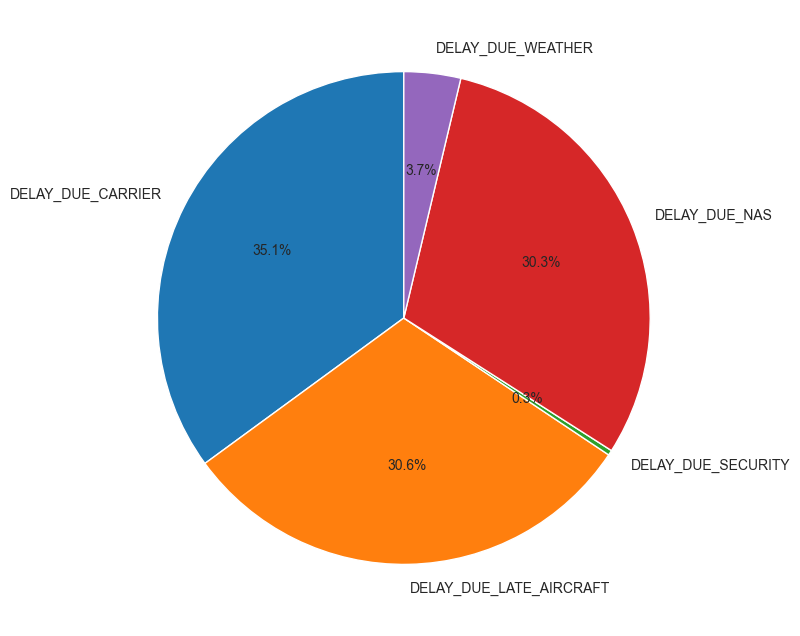

In [ ]:
#proportion of Flight Delays by Cause
sns.set_style("white")

plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90)

plt.show()

## Delay by airlines



In [ ]:
delay_by_airline = df_cleaned.groupBy("AIRLINE_CODE").agg(
    *[spark_sum(F.when(F.col(c) > 0, 1).otherwise(0)).alias(c) for c in delay_cols])

delay_by_airline_pd = delay_by_airline.toPandas()

<Figure size 1200x600 with 0 Axes>

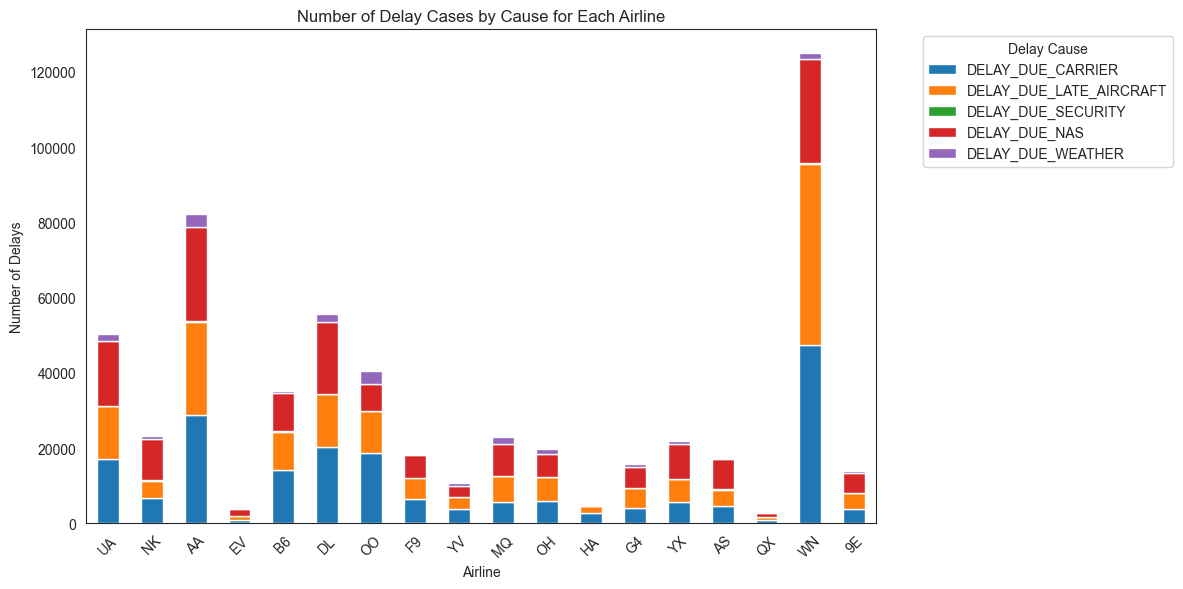

In [ ]:
delay_by_airline_pd = delay_by_airline_pd.set_index("AIRLINE_CODE")

plt.figure(figsize=(12,6))

delay_by_airline_pd.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6))

plt.title("Number of Delay Cases by Cause for Each Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Delays")

plt.legend(title="Delay Cause", bbox_to_anchor=(1.05,1))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Delay by airport

In [ ]:
# count delayed departures by ORIGIN
dep_delay_by_airport = df_cleaned.groupBy("ORIGIN").agg(
    spark_sum(F.when(F.col("DEP_DELAY") > 0, 1).otherwise(0)).alias("DEP_DELAY_COUNT"))
# count delayed arrivals by DEST
arr_delay_by_airport = df_cleaned.groupBy("DEST").agg(
    spark_sum(F.when(F.col("ARR_DELAY") > 0, 1).otherwise(0)).alias("ARR_DELAY_COUNT"))

arr_delay_by_airport = arr_delay_by_airport.withColumnRenamed("DEST", "AIRPORT")
dep_delay_by_airport = dep_delay_by_airport.withColumnRenamed("ORIGIN", "AIRPORT")

delay_by_airport = dep_delay_by_airport.join(arr_delay_by_airport, on="AIRPORT", how="outer").fillna(0)
delay_by_airport_pd = delay_by_airport.toPandas()

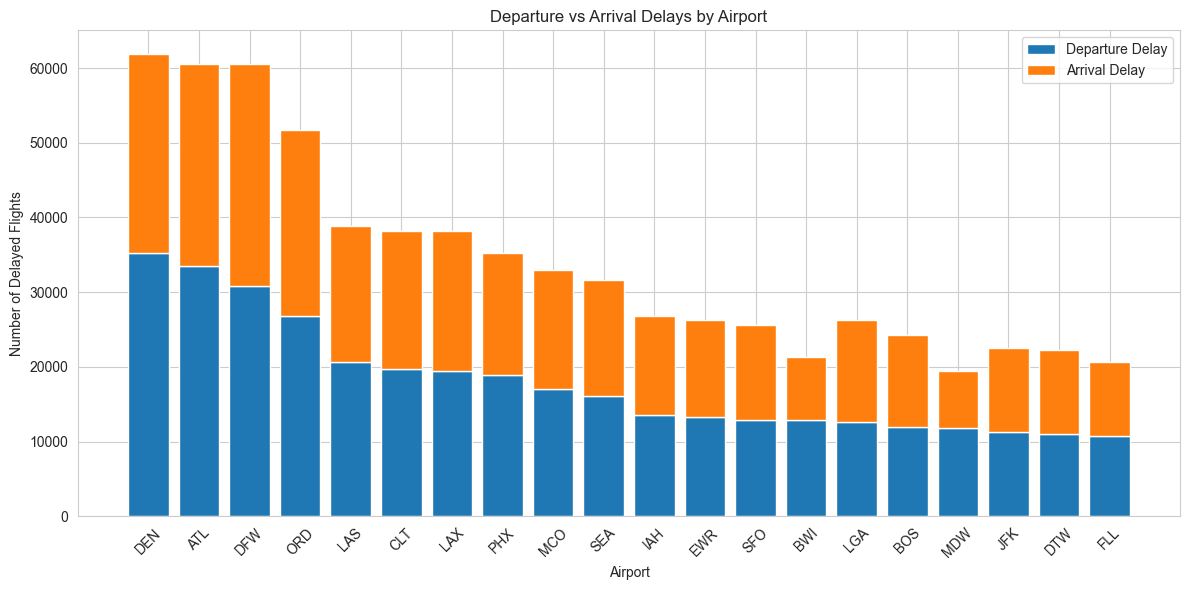

In [ ]:
top_airports = delay_by_airport_pd.sort_values(
    "DEP_DELAY_COUNT",
    ascending=False).head(20)
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))
x = range(len(top_airports))
plt.bar( x, top_airports["DEP_DELAY_COUNT"], label="Departure Delay")

plt.bar(x, top_airports["ARR_DELAY_COUNT"], bottom=top_airports["DEP_DELAY_COUNT"], label="Arrival Delay")

plt.xticks(x, top_airports["AIRPORT"], rotation=45)

plt.title("Departure vs Arrival Delays by Airport")
plt.xlabel("Airport")
plt.ylabel("Number of Delayed Flights")

plt.legend()

plt.tight_layout()
plt.show()

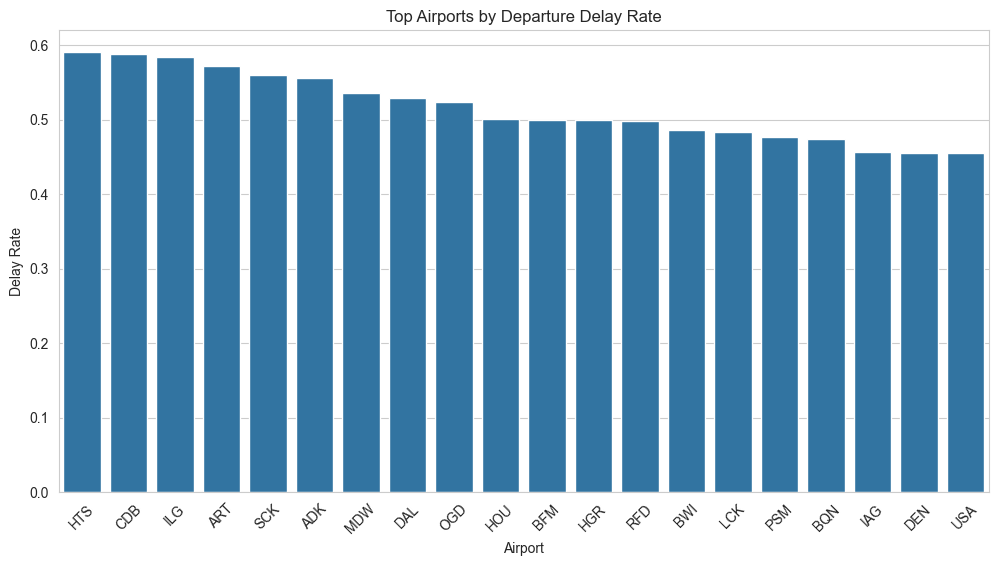

In [ ]:
airport_stats = df_cleaned.groupBy("ORIGIN").agg(
    F.count("*").alias("total_flights"),
    F.sum(F.when(F.col("DEP_DELAY") > 0, 1).otherwise(0)).alias("delayed_departures"))

airport_stats = airport_stats.withColumn("delay_rate", F.col("delayed_departures") / F.col("total_flights"))

airport_stats_pd = airport_stats.toPandas()

top_airports = airport_stats_pd.sort_values("delay_rate", ascending=False).head(20)

plt.figure(figsize=(12,6))

sns.barplot(x="ORIGIN", y="delay_rate", data=top_airports)

plt.title("Top Airports by Departure Delay Rate")
plt.xlabel("Airport")
plt.ylabel("Delay Rate")

plt.xticks(rotation=45)

plt.show()

# Correlation

In [89]:
assembler = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="features",
    handleInvalid="skip"
)

df_vector = assembler.transform(df).select("features")

In [90]:
corr_matrix = Correlation.corr(df_vector, "features", "pearson").head()[0]
corr_array = corr_matrix.toArray()

26/03/16 06:17:46 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [91]:
corr_df = pd.DataFrame(corr_array, index=numeric_cols, columns=numeric_cols)

<Axes: >

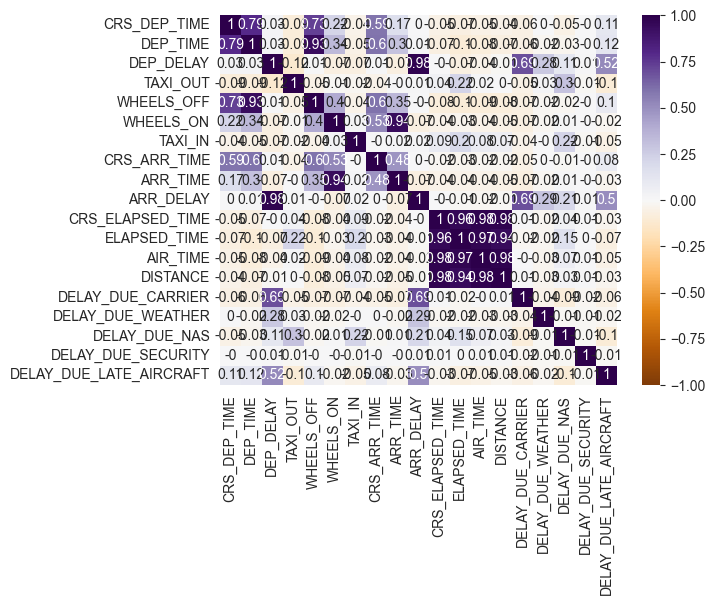

In [92]:
sns.heatmap(
    corr_df.round(2),
    cmap="PuOr",
    annot=True,
    vmin=-1,
    vmax=1,
    center=0
)

- May redundant:
AIR_TIME
ELAPSED_TIME
CRS_ELAPSED_TIME
DISTANCE
- May be lead to data leakage if using both in learning tasks: DEP_DELAY, ARR_DELAY

# Outlier

In [93]:
pdf = df_cleaned.select(numeric_cols).toPandas()

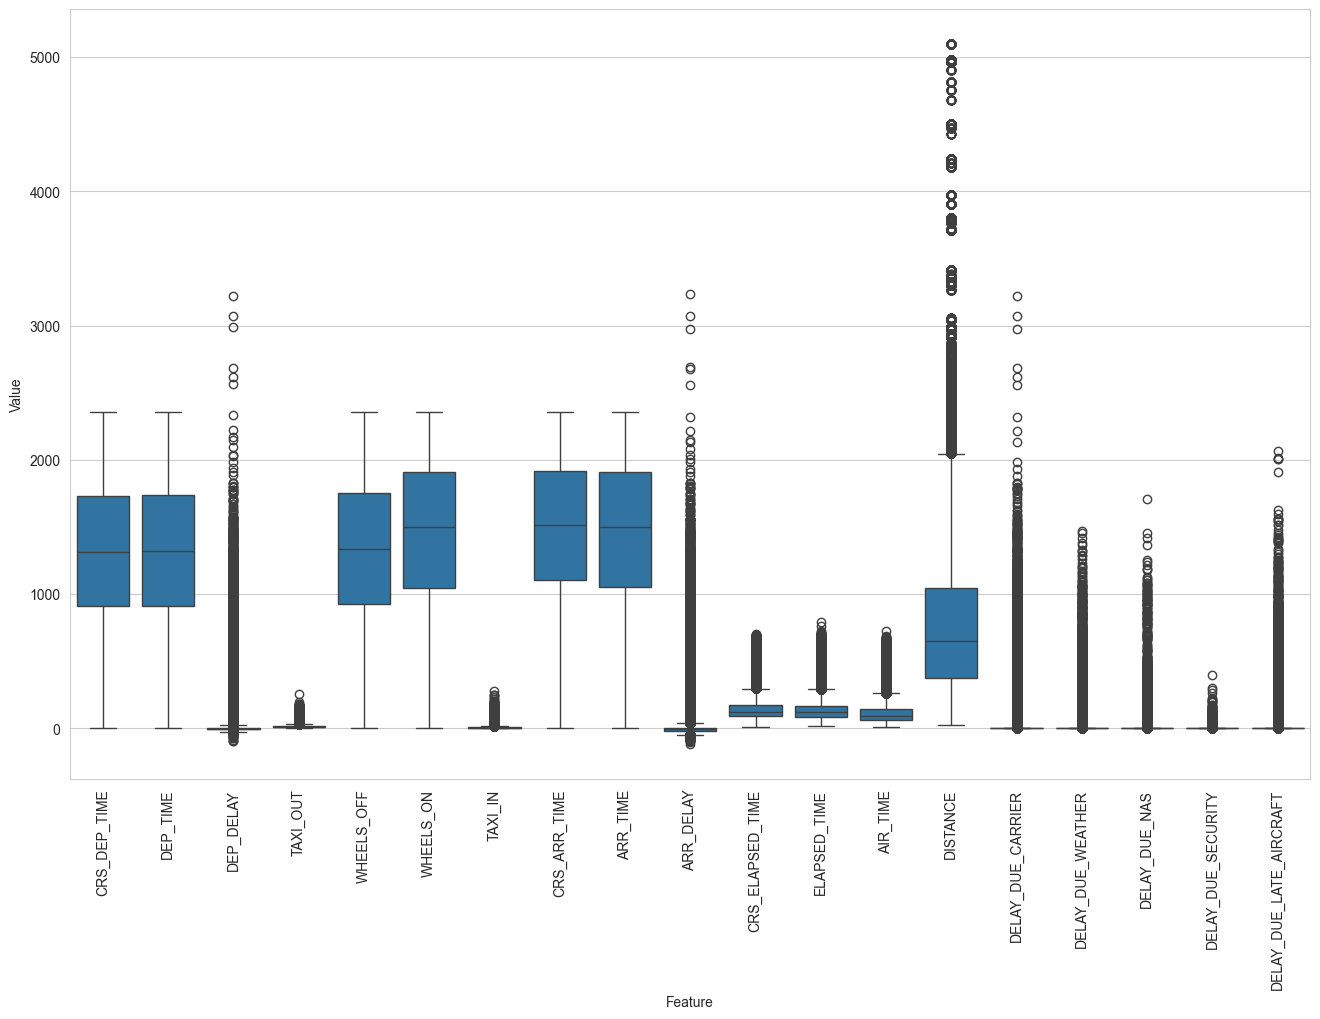

In [94]:
pdf_melt = pdf.melt(var_name="Feature", value_name="Value")

plt.figure(figsize=(16,10))
sns.boxplot(x="Feature", y="Value", data=pdf_melt)
plt.xticks(rotation=90)
plt.show()

In [95]:
df_cleaned.filter(F.col("DEP_DELAY") > 1000).show(50)

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|Hour|DayOfWeek|Month|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+
|2022-06-01|          UA|   19977|   

In [96]:
df_cleaned.filter(F.col("TAXI_OUT") > 100).show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|Hour|DayOfWeek|Month|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+
|2023-08-12|          DL|   19790|   

In [97]:
df_cleaned.withColumn(
    "speed",
    F.col("DISTANCE") / (F.col("AIR_TIME")/60)
).filter(F.col("speed") > 700).show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+-----------------+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|Hour|DayOfWeek|Month|            speed|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+--

In [98]:
df_cleaned.withColumn(
    "expected_airtime",
    F.col("DISTANCE") / 500 * 60
).withColumn(
    "airtime_diff",
    F.col("AIR_TIME") - F.col("expected_airtime")
).filter(
    F.abs(F.col("airtime_diff")) > 100
).show()

+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----------------------+----+---------+-----+------------------+-------------------+
|   FL_DATE|AIRLINE_CODE|DOT_CODE|FL_NUMBER|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ELAPSED_TIME|AIR_TIME|DISTANCE|DELAY_DUE_CARRIER|DELAY_DUE_WEATHER|DELAY_DUE_NAS|DELAY_DUE_SECURITY|DELAY_DUE_LATE_AIRCRAFT|Hour|DayOfWeek|Month|  expected_airtime|       airtime_diff|
+----------+------------+--------+---------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+------------+--------+--------+-----------------+-----------------+-------------+------------------+-----

In [ ]:
#before removing extreme outlier/noise
bef=df_cleaned.count()

In [ ]:
#remove noise
df_cleaned = df_cleaned.filter(
    (F.col("DEP_DELAY") <= 600) &
    (F.col("ARR_DELAY") <= 600) &
    (F.col("TAXI_OUT") <= 90) &
    (F.col("TAXI_IN") <= 60) &
    (F.col("DISTANCE") <= 3000)
)

In [ ]:
#after removing noise
aft=df_cleaned.count()

In [102]:
print("Number of extreme outliers/noise are:", bef-aft)

Number of extreme outliers/noise are: 10861


# Pre-processing

In [ ]:
#percentage of DEP_DELAY >= 15
df_cleaned.filter(F.col("DEP_DELAY") >= 15).count() / df_cleaned.count()*100

18.00184998553243

In [ ]:
df_cleaned = df_cleaned.withColumn("DELAYED", F.when(F.col("DEP_DELAY") > 15, 1).otherwise(0))

In [ ]:
df_cleaned = df_cleaned.withColumn("ROUTE",F.concat_ws("_", F.col("ORIGIN"), F.col("DEST")))

In [106]:
#save for classification and regression
df_cleaned.write.mode("overwrite").parquet("/Users/huynhphuongchi/Desktop/Unipi/Distributed data Analysis and Mining/flights_cleaned_full.parquet")

26/03/16 06:18:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/16 06:18:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/16 06:18:42 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/03/16 06:18:43 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/16 06:18:43 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/16 06:18:43 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/16 06:18:43 WARN MemoryManager: Total allocation exceeds 95.00%

In [ ]:
#AIRPORT_DELAY_RATE
airport_delay = df_cleaned.groupBy("ORIGIN").agg(F.count("*").alias("total_flights"), F.sum(F.when(F.col("DEP_DELAY") > 15, 1).otherwise(0)).alias("delayed_flights"))

airport_delay = airport_delay.withColumn("AIRPORT_DELAY_RATE", F.col("delayed_flights") / F.col("total_flights")).select("ORIGIN", "AIRPORT_DELAY_RATE")

df_cleaned = df_cleaned.join(airport_delay, on="ORIGIN", how="left")

In [ ]:
#ROUTE_DELAY_RATE
route_delay = df_cleaned.groupBy("ORIGIN", "DEST").agg(F.count("*").alias("total_flights"), F.sum(F.when(F.col("ARR_DELAY") > 15, 1).otherwise(0)).alias("delayed_flights"))

route_delay = route_delay.withColumn("ROUTE_DELAY_RATE", F.col("delayed_flights") / F.col("total_flights")).select("ORIGIN", "DEST", "ROUTE_DELAY_RATE")

df_cleaned = df_cleaned.join(route_delay, on=["ORIGIN","DEST"], how="left")

In [ ]:
#AIRLINE_DELAY_RATE
airline_delay = df_cleaned.groupBy("AIRLINE_CODE").agg(F.count("*").alias("total"), F.sum(F.when(F.col("ARR_DELAY") > 15,1).otherwise(0)).alias("delayed"))

airline_delay = airline_delay.withColumn("AIRLINE_DELAY_RATE", F.col("delayed") / F.col("total")).select("AIRLINE_CODE", "AIRLINE_DELAY_RATE")

df_cleaned = df_cleaned.join(airline_delay, on=["AIRLINE_CODE"], how="left")

In [110]:
df_cleaned=df_cleaned.drop("FL_DATE","ORIGIN","DEST","AIRLINE_CODE","DOT_CODE","FL_NUMBER","CRS_DEP_TIME","DEP_TIME",
                "WHEELS_OFF","WHEELS_ON","DELAY_DUE_CARRIER","DELAY_DUE_WEATHER",
                "DELAY_DUE_NAS","DELAY_DUE_SECURITY","DELAY_DUE_LATE_AIRCRAFT","ARR_TIME",
                "AIR_TIME","ELAPSED_TIME","CRS_ARR_TIME")

In [111]:
df_cleaned.printSchema()

root
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- DISTANCE: double (nullable = true)
 |-- Hour: long (nullable = true)
 |-- DayOfWeek: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- DELAYED: integer (nullable = false)
 |-- ROUTE: string (nullable = false)
 |-- AIRPORT_DELAY_RATE: double (nullable = true)
 |-- ROUTE_DELAY_RATE: double (nullable = true)
 |-- AIRLINE_DELAY_RATE: double (nullable = true)



In [112]:
#save cleaned dataframe
clean_path = "/Users/huynhphuongchi/Desktop/Unipi/Distributed data Analysis and Mining/flights_cleaned.parquet"

df_cleaned.write.mode("overwrite").parquet(clean_path)

26/03/16 06:18:49 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/16 06:18:49 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/16 06:18:49 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/03/16 06:18:49 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/16 06:18:49 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/16 06:18:50 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/16 06:18:50 WARN MemoryManager: Total allocation exceeds 95.00%